#CELL 1
# Module 2.4 — Salary Prediction

This notebook predicts employee monthly income using a Gradient Boosting Regressor.

It evaluates the model using MAE, RMSE, and R², analyzes residuals, and saves a
salary prediction model with an estimated salary range.

In [6]:
#CELL 2
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.load import load_raw_ibm_hr
from src.data.preprocess import clean_hr_data
from src.modeling.salary import (
    build_salary_pipeline,
    evaluate_salary_model,
    predict_salary_range,
    prepare_salary_data,
    save_salary_model,
    split_salary_data,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

Project root: c:\Users\Anvesha Garg\Desktop\workforce360\workforce360


In [7]:
#CELL 3
raw_df = load_raw_ibm_hr()
clean_df = clean_hr_data(raw_df)

X, y = prepare_salary_data(clean_df)
X_train, X_test, y_train, y_test = split_salary_data(X, y)

print(f"Training employees: {len(X_train):,}")
print(f"Test employees: {len(X_test):,}")
print(f"Average monthly income: ${y.mean():,.0f}")

X.head()

Training employees: 1,176
Test employees: 294
Average monthly income: $6,503


,department,job_role,education_field,gender,overtime_flag,age,distance_from_home,total_working_years,years_at_company,years_in_current_role,years_since_promotion,job_level,performance_rating,job_satisfaction,work_life_balance
0,Sales,Sales Executive,Life Sciences,Female,1,41,1,8,6,4,0,2,3,4,1
1,Research & Development,Research Scientist,Life Sciences,Male,0,49,8,10,10,7,1,2,4,2,3
2,Research & Development,Laboratory Technician,Other,Male,1,37,2,7,0,0,0,1,3,3,3
3,Research & Development,Research Scientist,Life Sciences,Female,1,33,3,8,8,7,3,1,3,3,3
4,Research & Development,Laboratory Technician,Medical,Male,0,27,2,6,2,2,2,1,3,2,3


In [8]:
#CELL 4
salary_model = build_salary_pipeline()

salary_model.fit(X_train, y_train)

print("Salary model trained successfully.")

Salary model trained successfully.


In [9]:
#CELL 5
salary_metrics = evaluate_salary_model(
    model=salary_model,
    X_test=X_test,
    y_test=y_test,
)

salary_metrics

{'mae': 807.2756071184012,
 'rmse': 1095.2242558231846,
 'r2': 0.9451158205840996}

#CELL 6
## Model evaluation

- **MAE** is the average absolute difference between predicted and actual monthly income.
- **RMSE** penalizes larger prediction errors more heavily.
- **R²** measures how much income variation the model explains.

A lower MAE and RMSE indicate better accuracy. An R² closer to 1 indicates stronger explanatory power.

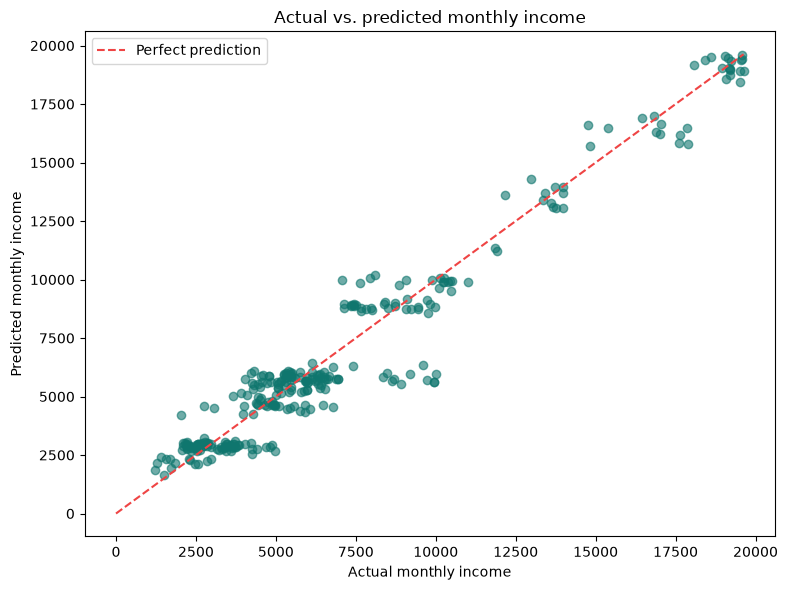

In [10]:
#CELL 7
predictions = salary_model.predict(X_test)

results_df = pd.DataFrame(
    {
        "actual_monthly_income": y_test.values,
        "predicted_monthly_income": predictions,
    }
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    results_df["actual_monthly_income"],
    results_df["predicted_monthly_income"],
    alpha=0.6,
    color="#0f766e",
)

limit = max(
    results_df["actual_monthly_income"].max(),
    results_df["predicted_monthly_income"].max(),
)

ax.plot(
    [0, limit],
    [0, limit],
    color="#ef4444",
    linestyle="--",
    label="Perfect prediction",
)

ax.set_xlabel("Actual monthly income")
ax.set_ylabel("Predicted monthly income")
ax.set_title("Actual vs. predicted monthly income")
ax.legend()

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "salary_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

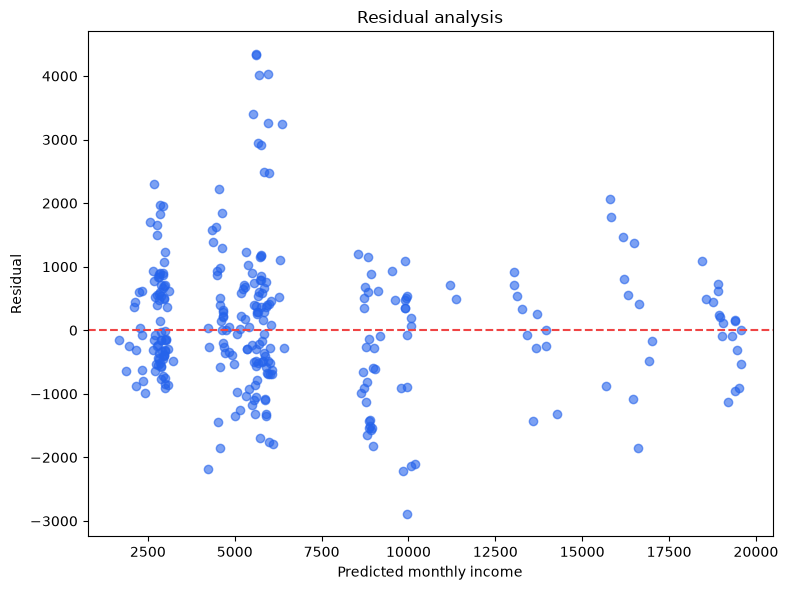

In [11]:
#CELL 8
results_df["residual"] = (
    results_df["actual_monthly_income"]
    - results_df["predicted_monthly_income"]
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    results_df["predicted_monthly_income"],
    results_df["residual"],
    alpha=0.6,
    color="#2563eb",
)

ax.axhline(0, color="#ef4444", linestyle="--")

ax.set_xlabel("Predicted monthly income")
ax.set_ylabel("Residual")
ax.set_title("Residual analysis")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "salary_residual_analysis.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [12]:
#CELL 9 
sample_employee = X_test.iloc[[0]]

salary_range = predict_salary_range(
    model=salary_model,
    employee_row=sample_employee,
)

salary_range

{'point_estimate': 5993.454294875252,
 'lower_bound': 5394.108865387727,
 'upper_bound': 6592.799724362778}

In [13]:
#CELL 10
model_path = save_salary_model(
    model=salary_model,
    metrics=salary_metrics,
)

print(f"Saved salary model to: {model_path}")
print(f"Model size: {model_path.stat().st_size:,} bytes")

Saved salary model to: C:\Users\Anvesha Garg\Desktop\workforce360\workforce360\models\salary_model.joblib
Model size: 274,263 bytes


In [14]:
#CELL 11
pd.DataFrame([salary_metrics]).to_csv(
    ROOT / "reports" / "salary_model_metrics.csv",
    index=False,
)

print("Saved:")
print(ROOT / "reports" / "salary_model_metrics.csv")

Saved:
c:\Users\Anvesha Garg\Desktop\workforce360\workforce360\reports\salary_model_metrics.csv


#CELL 12
## Results

- The Gradient Boosting Regressor predicts monthly income from employee profile features.
- Model performance is measured using MAE, RMSE, and R².
- Residual plots help identify systematic prediction errors.
- The model artifact includes the fitted pipeline, evaluation metrics, and feature list.
- Salary estimates are statistical analysis and must not be used for automated compensation decisions.